# Prediction quality by annotation and evidence class strata

This notebook connects trained-head performance to the ion groups described in part 0. It separates historical population descriptions from groups derived exclusively from training data and measures paired changes relative to the BCE baseline.

## Introduction

A pooled macro AP can conceal opposite responses of rare, common and largely undetectable ions. Grouped evaluation identifies which classes benefit from each head and whether the gain is specific to classes that are easy to separate by the spectral evidence rule.

### Assumptions

Historical part-0 groups describe the full annotated population, including held-out pixels; they are descriptive strata, not inputs to head selection. Their saved threshold is retained explicitly and need not equal the training threshold. Train-only groups use the same definitions at the campaign evidence threshold. Every join is by exact `class_name`, never by row position. Seed pairs, rather than classes or pixels, are the units for intervals.

### Notation

For ion c, P_c, N_c and U_c are training state counts, prevalence is P_c/(P_c+N_c+U_c), and the negative fraction among unannotated entries is N_c/(N_c+U_c). AP_c is the class-specific annotation or operational-P/N average precision. A stratum is a fixed set of class identities shared by every model.

In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import display

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.visualization import predictive as plots

current = Path.cwd().resolve()
repository_root = next(path for path in (current, *current.parents) if (path / "pyproject.toml").is_file())
notebook_directory = repository_root / "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded"
settings_path = Path(os.environ.get("MSI_PREDICTIVE_SETTINGS", notebook_directory / "analysis_settings.yaml"))
settings = campaign.load_settings(settings_path)
RESULTS = notebook_directory / "part_8_class_stratification_results"
RESULTS.mkdir(parents=True, exist_ok=True)


2026-09-08 10:29:11,319 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-08 10:29:11,322 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-08 10:29:11,675 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-08 10:29:11,677 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-08 10:29:11,678 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-08 10:29:11,679 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


## Class identity, historical groups and training-only groups

### Methodology

#### Theoretical

The historical `part0_regime` is copied exactly from `class_regimes.csv`: undetectable if at least 95% of unannotated entries are N; otherwise rare if annotation prevalence is below 1%; otherwise common. `train_regime` applies those same cut-offs to train-only state counts at 0.0119/radius=1. These groups differ from train support bins (0, 1–9, 10–99, 100+ positives). Additional descriptive strata are part-0 evidence AUC (≤0.5, (0.5,0.7], >0.7) and 100-Da m/z windows.

#### Implementation

Join the part-0 prevalence, regime and evidence-separation tables to cached train counts using unique class names. Require identical complete class catalogues. Preserve both thresholds, continuous properties and group labels. The regime transition table counts class identities, not pixels or training repetitions.

#### Figure descriptions

The tables list the taxonomy and counts for each historical-to-training regime transition. A changed regime does not imply that a class changed biologically: threshold, population and training sample differ.

In [2]:
import json
from msi_autoencoder_wrapper.analysis.autoencoder.heads.class_stratification import class_strata, stratified_metrics

manifest = json.loads((Path(settings["cache_directory"]) / "latest.json").read_text())
run_directory = Path(manifest["run_directory"])
strata = class_strata(
    pd.read_csv(notebook_directory / "part_0_1_annotation_population_results/class_prevalence.csv"),
    pd.read_csv(notebook_directory / "part_0_2_evidence_threshold_selection_results/class_regimes.csv"),
    pd.read_csv(notebook_directory / "part_0_2_evidence_threshold_selection_results/class_separation.csv"),
    pd.read_csv(run_directory / "train_class_states.csv"),
)
transitions = strata.groupby(["part0_regime", "train_regime"]).size().rename("classes").reset_index()
display(strata)
display(transitions)
reports.save_tables(RESULTS, class_strata=strata, regime_transitions=transitions)

2026-09-08 10:29:11,716 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.heads.class_stratification:61 | Joined 508 class identities to historical and train-only strata.


,class_name,positive_entries,negative_entries,uncertain_entries,relative_threshold,bin_radius,mz,part0_prevalence,part0_regime,part0_threshold,part0_radius,part0_negative_fraction,evidence_auc,train_prevalence,train_negative_fraction,train_regime,train_support,part0_evidence_separation,mz_window
0,C10H12N2O5|-H,20,19742,13888,0.0119,1,239.067345,0.000442,rare,0.005309,1,0.425493,0.683105,0.000594,0.587035,rare,10-99 positives,0.5 < AUC <= 0.7,200-300 m/z
1,C10H12N4O5|-H,218,6245,27187,0.0119,1,267.073493,0.006502,rare,0.005309,1,0.050398,0.738700,0.006478,0.186797,rare,100+ positives,AUC > 0.7,200-300 m/z
2,C10H13N4O8P|-H,6306,4959,22385,0.0119,1,347.039824,0.186702,common,0.005309,1,0.119203,0.500128,0.187400,0.181356,common,100+ positives,0.5 < AUC <= 0.7,300-400 m/z
3,C10H14N4O5|-H,1276,16917,15457,0.0119,1,269.089143,0.037554,common,0.005309,1,0.442969,0.678259,0.037920,0.522549,common,100+ positives,0.5 < AUC <= 0.7,200-300 m/z
4,C10H14N5O7P|-H,6698,3995,22957,0.0119,1,346.055808,0.199138,common,0.005309,1,0.100142,0.326039,0.199049,0.148226,common,100+ positives,AUC <= 0.5,300-400 m/z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,C9H16N6O2|-H,30,19751,13869,0.0119,1,239.126197,0.000806,rare,0.005309,1,0.425676,0.802910,0.000892,0.587478,rare,10-99 positives,AUC > 0.7,200-300 m/z
504,C9H16O9|-H,208,6245,27197,0.0119,1,267.072156,0.006305,rare,0.005309,1,0.050388,0.736067,0.006181,0.186741,rare,100+ positives,AUC > 0.7,200-300 m/z
505,C9H17NO4|-H,13,20768,12869,0.0119,1,202.108482,0.000247,rare,0.005309,1,0.534083,0.769173,0.000386,0.617415,rare,10-99 positives,AUC > 0.7,200-300 m/z
506,C9H17NO5|-H,1028,20386,12236,0.0119,1,218.103396,0.030978,common,0.005309,1,0.310953,0.422083,0.030550,0.624916,common,100+ positives,AUC <= 0.5,200-300 m/z


,part0_regime,train_regime,classes
0,common,common,310
1,rare,common,5
2,rare,rare,193


2026-09-08 10:29:11,745 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 2 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_8_class_stratification_results.


### Remarks

The historical threshold is not silently replaced by the campaign threshold. Full-population evidence AUC is a descriptive covariate, not an independently validated predictor of head performance.

### Notes


## Stratified ranking and paired baseline effects

### Methodology

#### Theoretical

Within each model, split, evaluation population and fixed class stratum, calculate the unweighted mean of eligible per-class AP/AUC. Eligibility is inherited from the main prediction analysis: positive training support and both positive and comparison-zero evaluation examples. A group with no eligible class remains NaN, with an explicit zero denominator. Baseline effects are differences of these matched-stratum macro means for the same derived seed and compatible data/backbone/training configuration.

#### Implementation

Preserve enriched class-level records and total/eligible class counts before averaging duplicate tasks within each seed. Compute all comparisons using the existing paired estimator, then retain pairs involving historical BCE. Intervals reflect variation across at most five seeds; they are exploratory and not adjusted for multiple comparisons. Both validation and test are exported; plots focus on validation. This analysis does not modify the validation-only shortlist.

#### Figure descriptions

For each grouping and stratum: x=head, y=validation annotation-retrieval AP; each overlaid point is one independent seed after averaging duplicate tasks, and the violin includes all available seeds. The paired-effect table reports left-minus-right AP, its interval and the number of matched seeds; the displayed operand order determines the sign. Coverage tables show how many classes contribute rather than hiding undefined groups.

2026-09-08 10:29:19,465 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_campaign:250 | Audited 65 model manifests across 2 sources.


,label,split,population,grouping,stratum,metric,mean,std,seeds
31,balanced_bce (ClassBalancedMultiLabelBCELoss),test,annotation_retrieval,part0_regime,common,average_precision,0.833694,0.004861,5
34,balanced_bce (ClassBalancedMultiLabelBCELoss),test,annotation_retrieval,part0_regime,rare,average_precision,0.425551,0.007450,5
133,balanced_bce (ClassBalancedMultiLabelBCELoss),train,annotation_retrieval,part0_regime,common,average_precision,0.834061,0.004833,5
136,balanced_bce (ClassBalancedMultiLabelBCELoss),train,annotation_retrieval,part0_regime,rare,average_precision,0.403818,0.011076,5
235,balanced_bce (ClassBalancedMultiLabelBCELoss),validation,annotation_retrieval,part0_regime,common,average_precision,0.834202,0.004113,5
238,balanced_bce (ClassBalancedMultiLabelBCELoss),validation,annotation_retrieval,part0_regime,rare,average_precision,0.443056,0.011530,5
337,bce_global_positive_penalty (PositiveWeightedM...,test,annotation_retrieval,part0_regime,common,average_precision,0.837446,0.005659,5
340,bce_global_positive_penalty (PositiveWeightedM...,test,annotation_retrieval,part0_regime,rare,average_precision,0.426252,0.025720,5
439,bce_global_positive_penalty (PositiveWeightedM...,train,annotation_retrieval,part0_regime,common,average_precision,0.837662,0.005112,5
442,bce_global_positive_penalty (PositiveWeightedM...,train,annotation_retrieval,part0_regime,rare,average_precision,0.398816,0.013107,5


,grouping,stratum,split,population,total_classes,eligible_classes
0,part0_regime,common,test,annotation_retrieval,310,310
1,part0_regime,rare,test,annotation_retrieval,198,198
2,part0_regime,common,test,operational_pn,310,310
3,part0_regime,rare,test,operational_pn,198,198
4,part0_regime,common,train,annotation_retrieval,310,310
...,...,...,...,...,...,...
11737,mz_window,400-500 m/z,validation,operational_pn,44,44
11738,mz_window,500-600 m/z,validation,operational_pn,33,33
11739,mz_window,600-700 m/z,validation,operational_pn,18,18
11740,mz_window,700-800 m/z,validation,operational_pn,81,81


,left,right,left_source,right_source,left_condition,right_condition,split,population,grouping,stratum,metric,pairs,mean_difference,median_difference,positive_pairs,ci_low,ci_high,reason
205,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,validation,annotation_retrieval,mz_window,200-300 m/z,average_precision,5,-0.000464,-0.001011,2,-0.002513,0.001585,Exploratory unadjusted interval across seeds
208,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,validation,annotation_retrieval,mz_window,300-400 m/z,average_precision,5,-0.002139,-0.005317,1,-0.013413,0.009135,Exploratory unadjusted interval across seeds
211,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,validation,annotation_retrieval,mz_window,400-500 m/z,average_precision,5,-0.001439,-0.004022,2,-0.012511,0.009632,Exploratory unadjusted interval across seeds
214,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,validation,annotation_retrieval,mz_window,500-600 m/z,average_precision,5,-0.006572,-0.010930,1,-0.018390,0.005246,Exploratory unadjusted interval across seeds
217,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_global_positive_penalty (PositiveWeightedM...,historical_bce,predictive_initial,81fea4dad4ea,061bcbfb8c04,validation,annotation_retrieval,mz_window,600-700 m/z,average_precision,5,-0.007505,-0.007490,0,-0.010854,-0.004157,Exploratory unadjusted interval across seeds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2383,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_per_class_positive_penalty (PositiveWeight...,historical_bce,predictive_initial,81fea4dad4ea,e27ded54dfca,validation,annotation_retrieval,train_regime,common,average_precision,5,-0.007308,-0.007337,1,-0.014052,-0.000565,Exploratory unadjusted interval across seeds
2386,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_per_class_positive_penalty (PositiveWeight...,historical_bce,predictive_initial,81fea4dad4ea,e27ded54dfca,validation,annotation_retrieval,train_regime,rare,average_precision,5,-0.000098,0.000769,3,-0.011558,0.011361,Exploratory unadjusted interval across seeds
2389,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_per_class_positive_penalty (PositiveWeight...,historical_bce,predictive_initial,81fea4dad4ea,e27ded54dfca,validation,annotation_retrieval,train_support,1-9 positives,average_precision,5,0.010202,0.008493,4,-0.021628,0.042031,Exploratory unadjusted interval across seeds
2392,balanced_bce (ClassBalancedMultiLabelBCELoss),bce_per_class_positive_penalty (PositiveWeight...,historical_bce,predictive_initial,81fea4dad4ea,e27ded54dfca,validation,annotation_retrieval,train_support,10-99 positives,average_precision,5,0.000943,0.001480,3,-0.004374,0.006260,Exploratory unadjusted interval across seeds


2026-09-08 10:29:39,470 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 6 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_8_class_stratification_results.


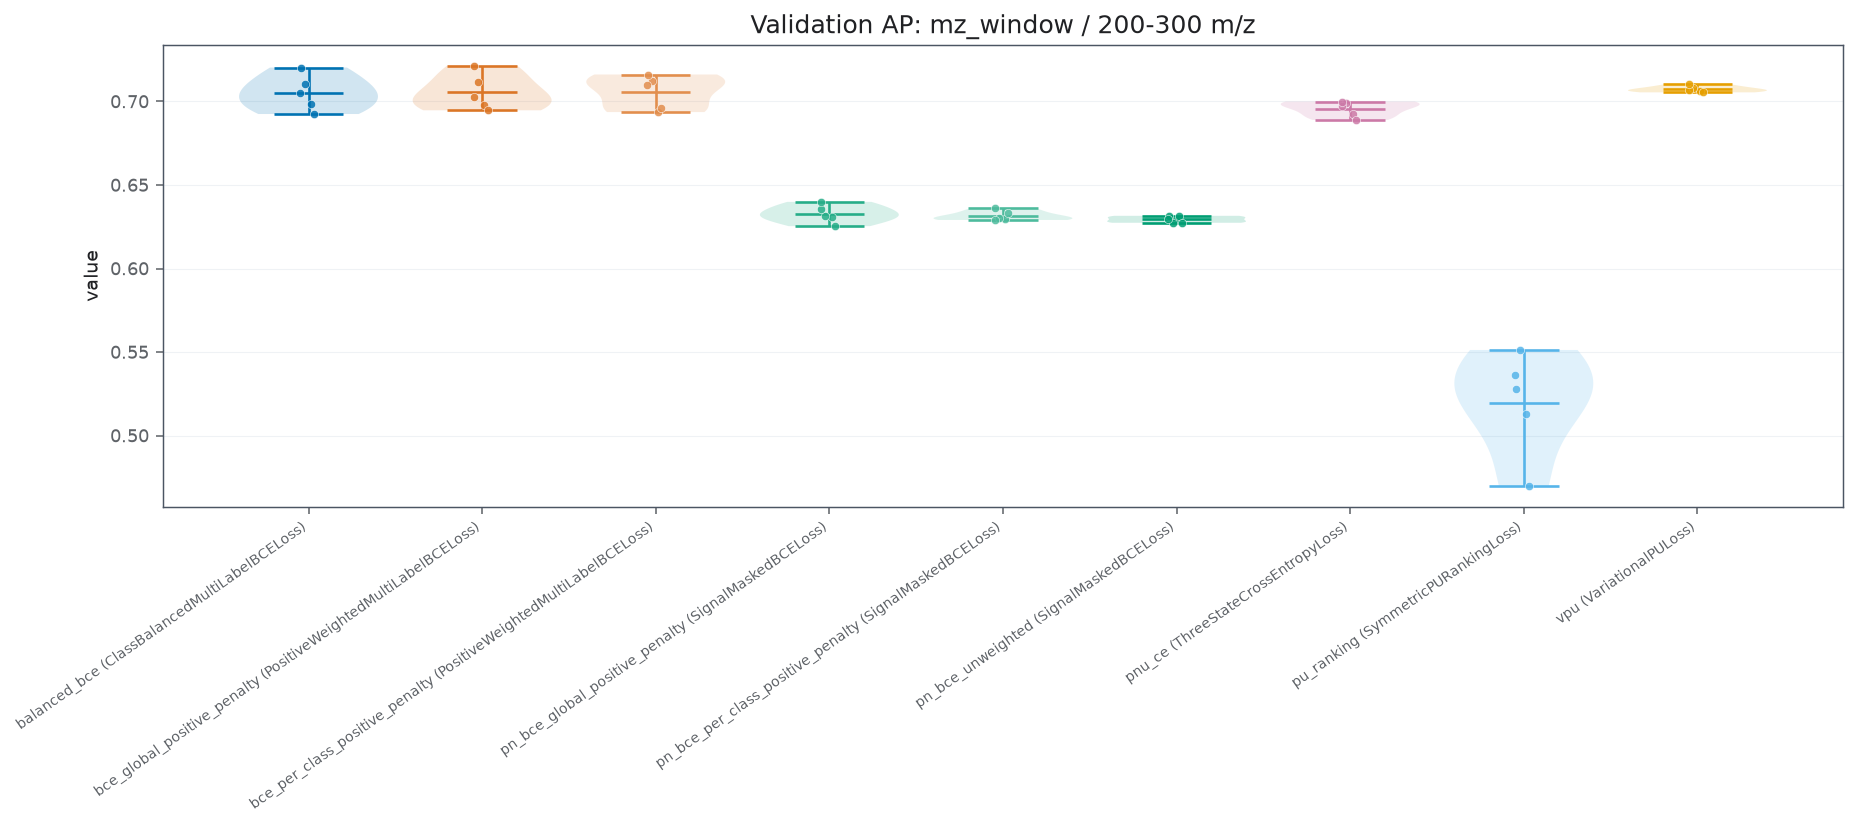

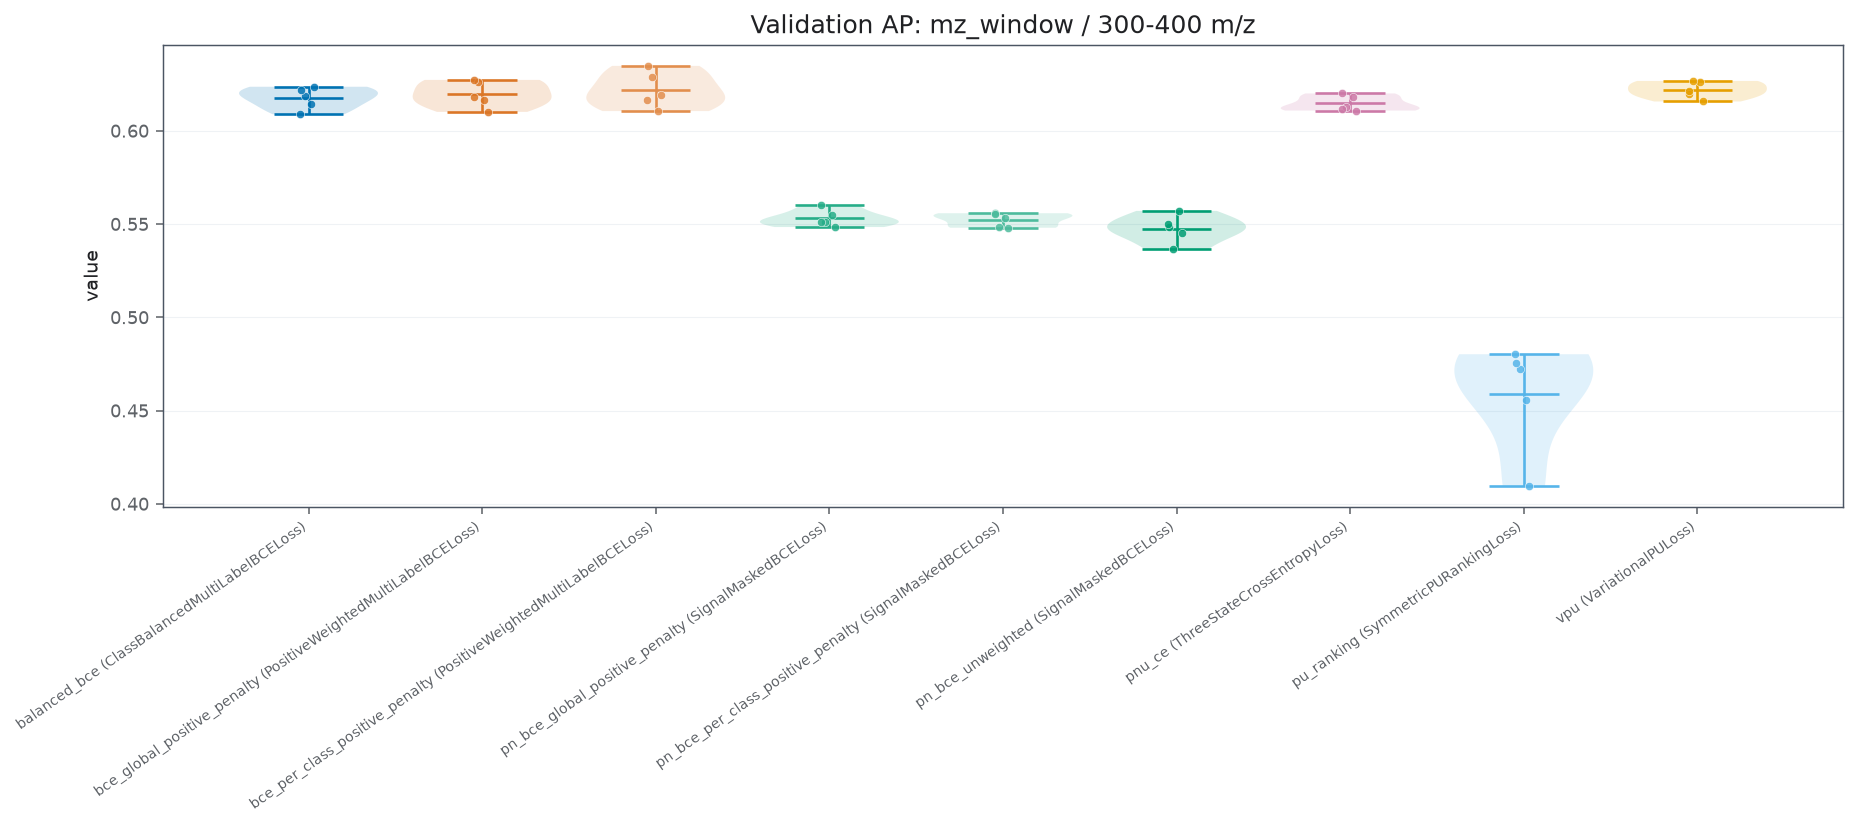

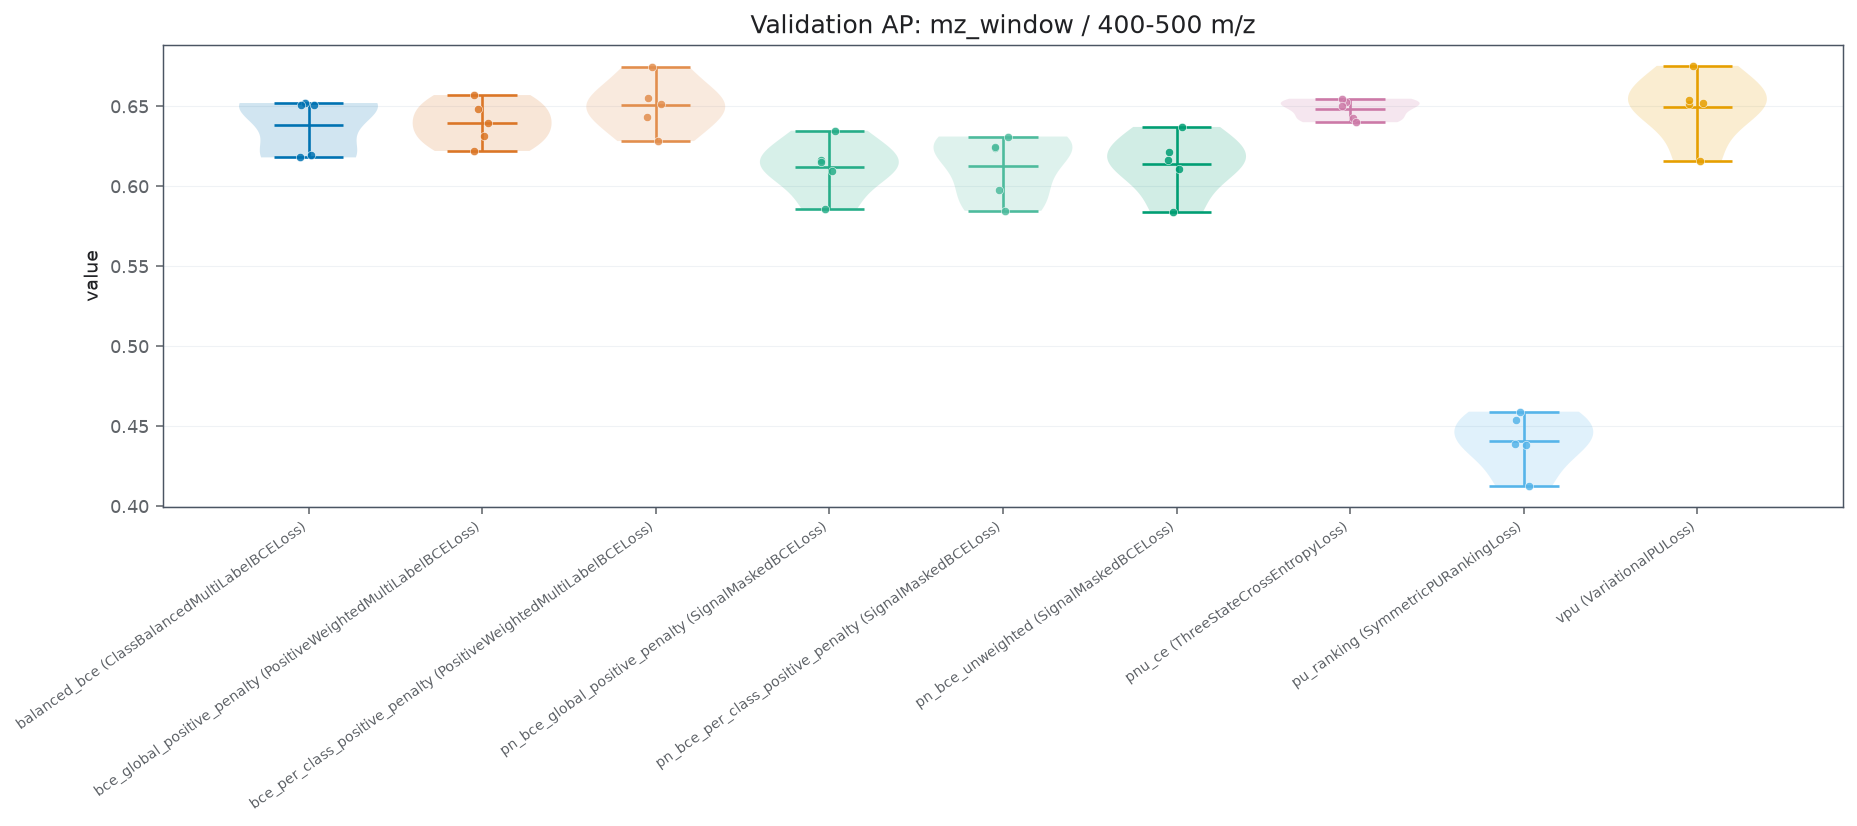

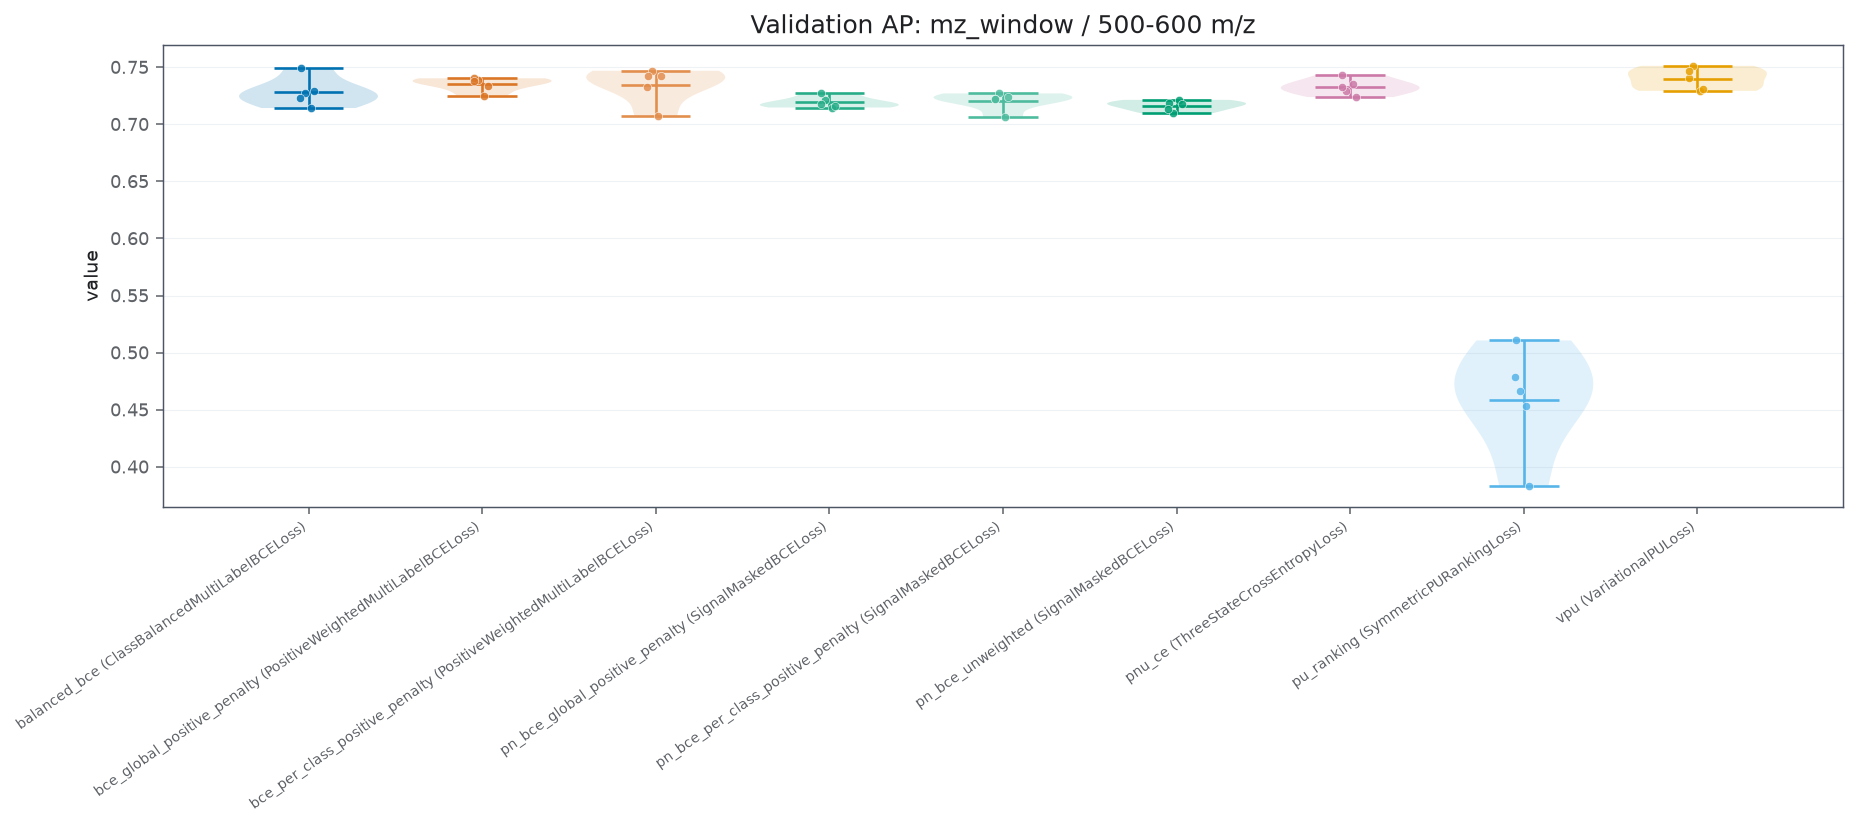

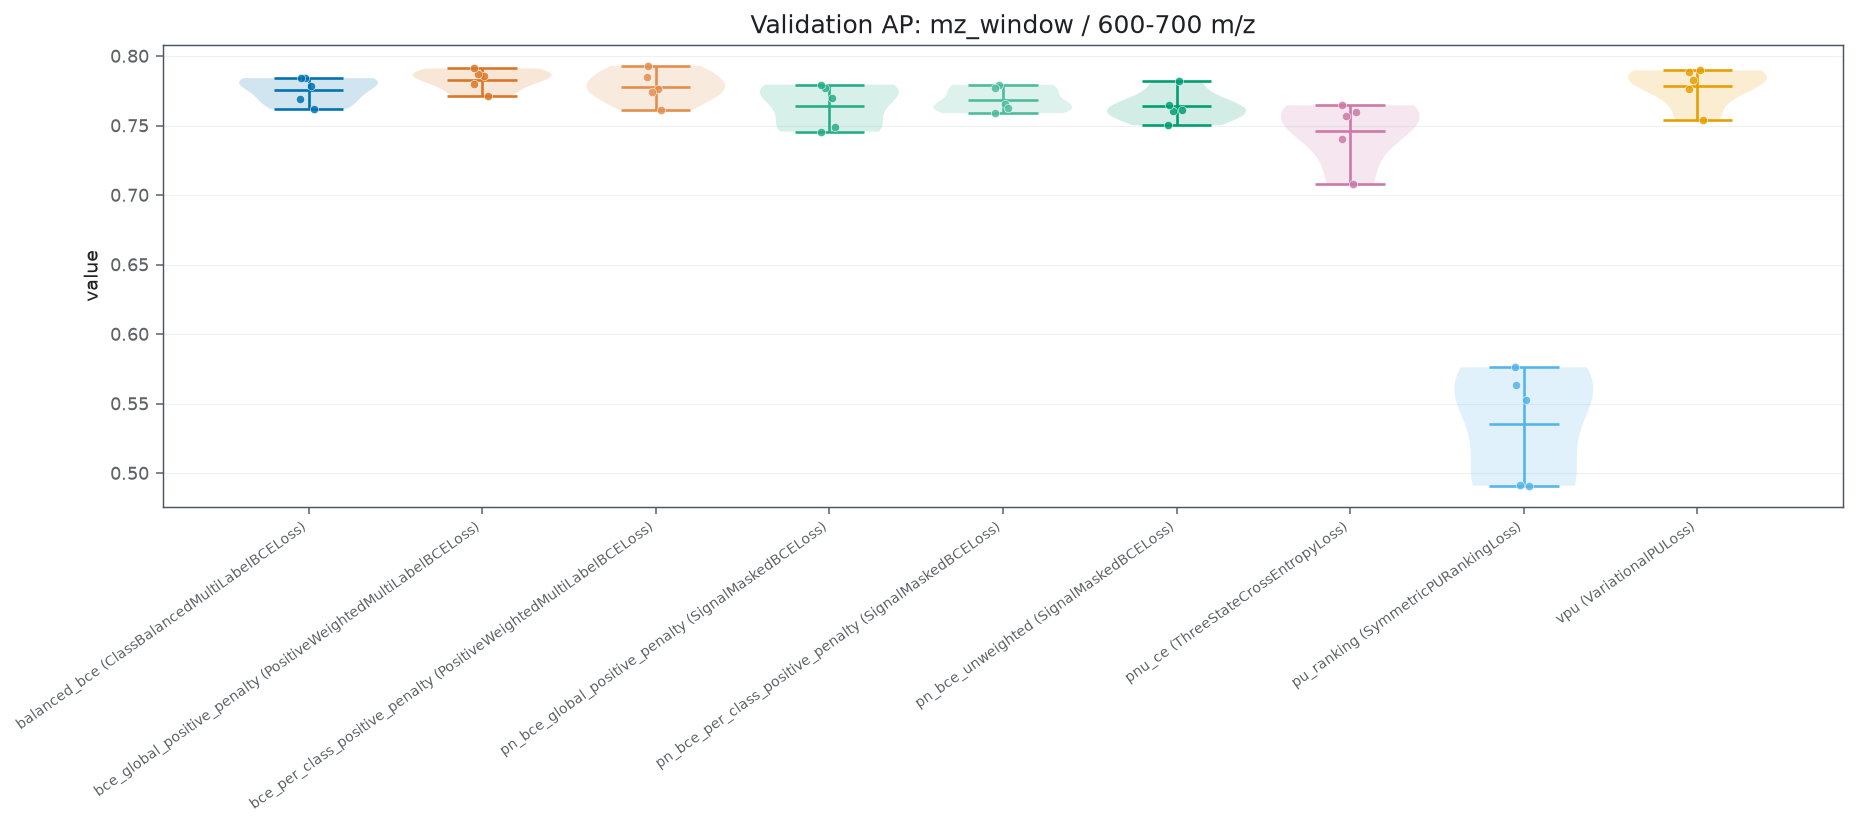

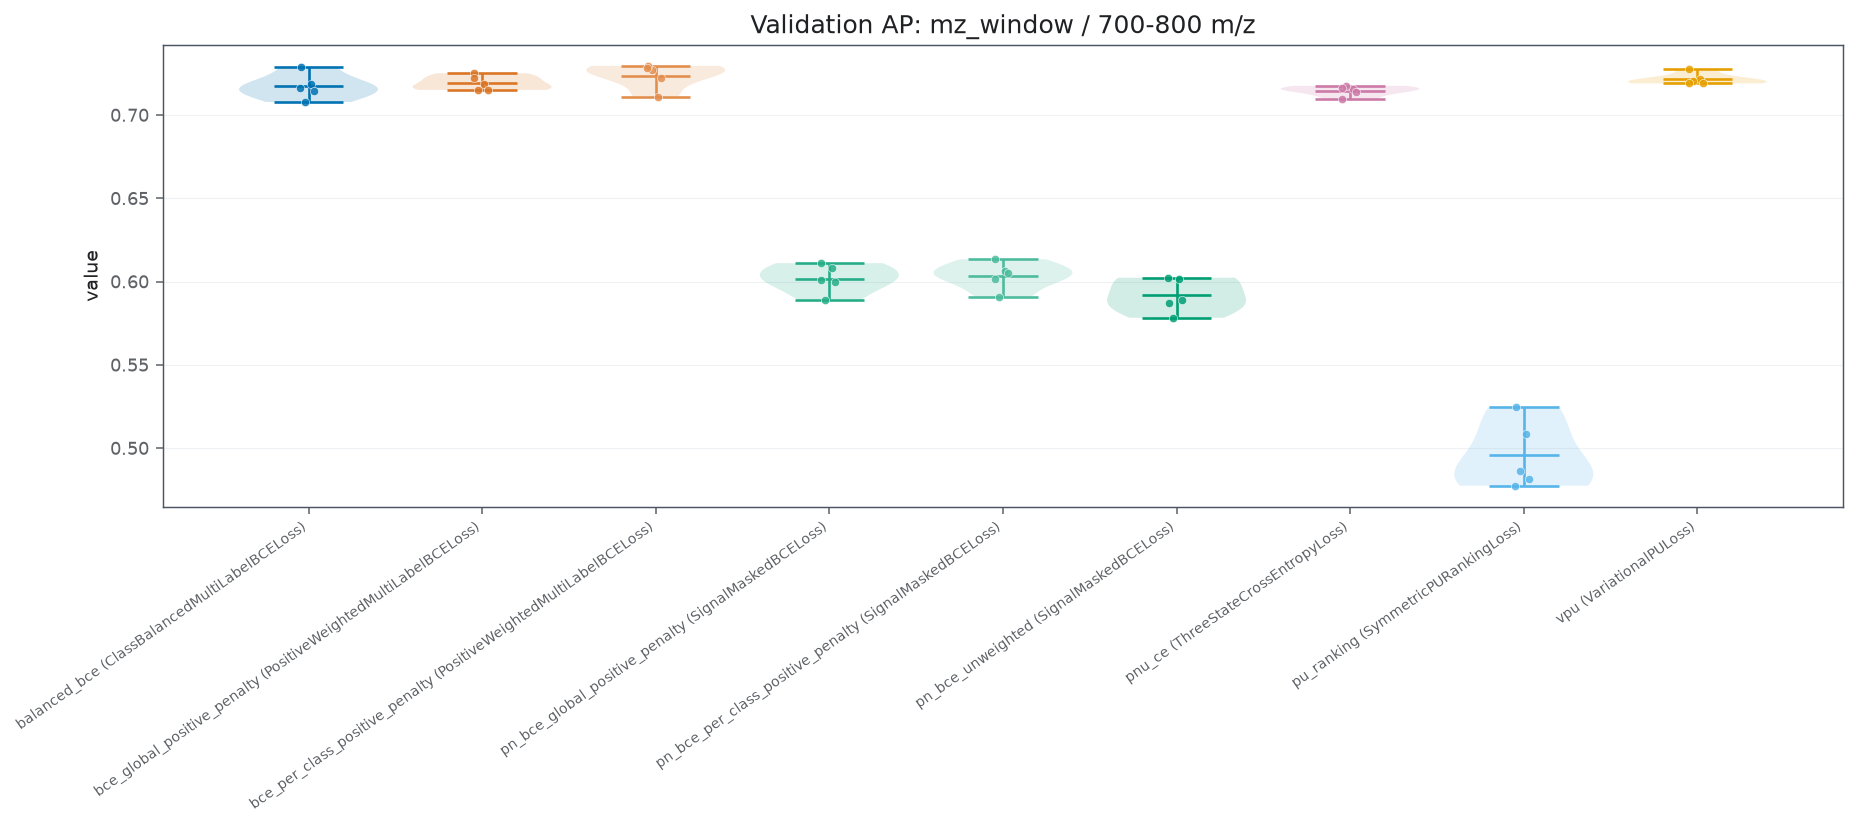

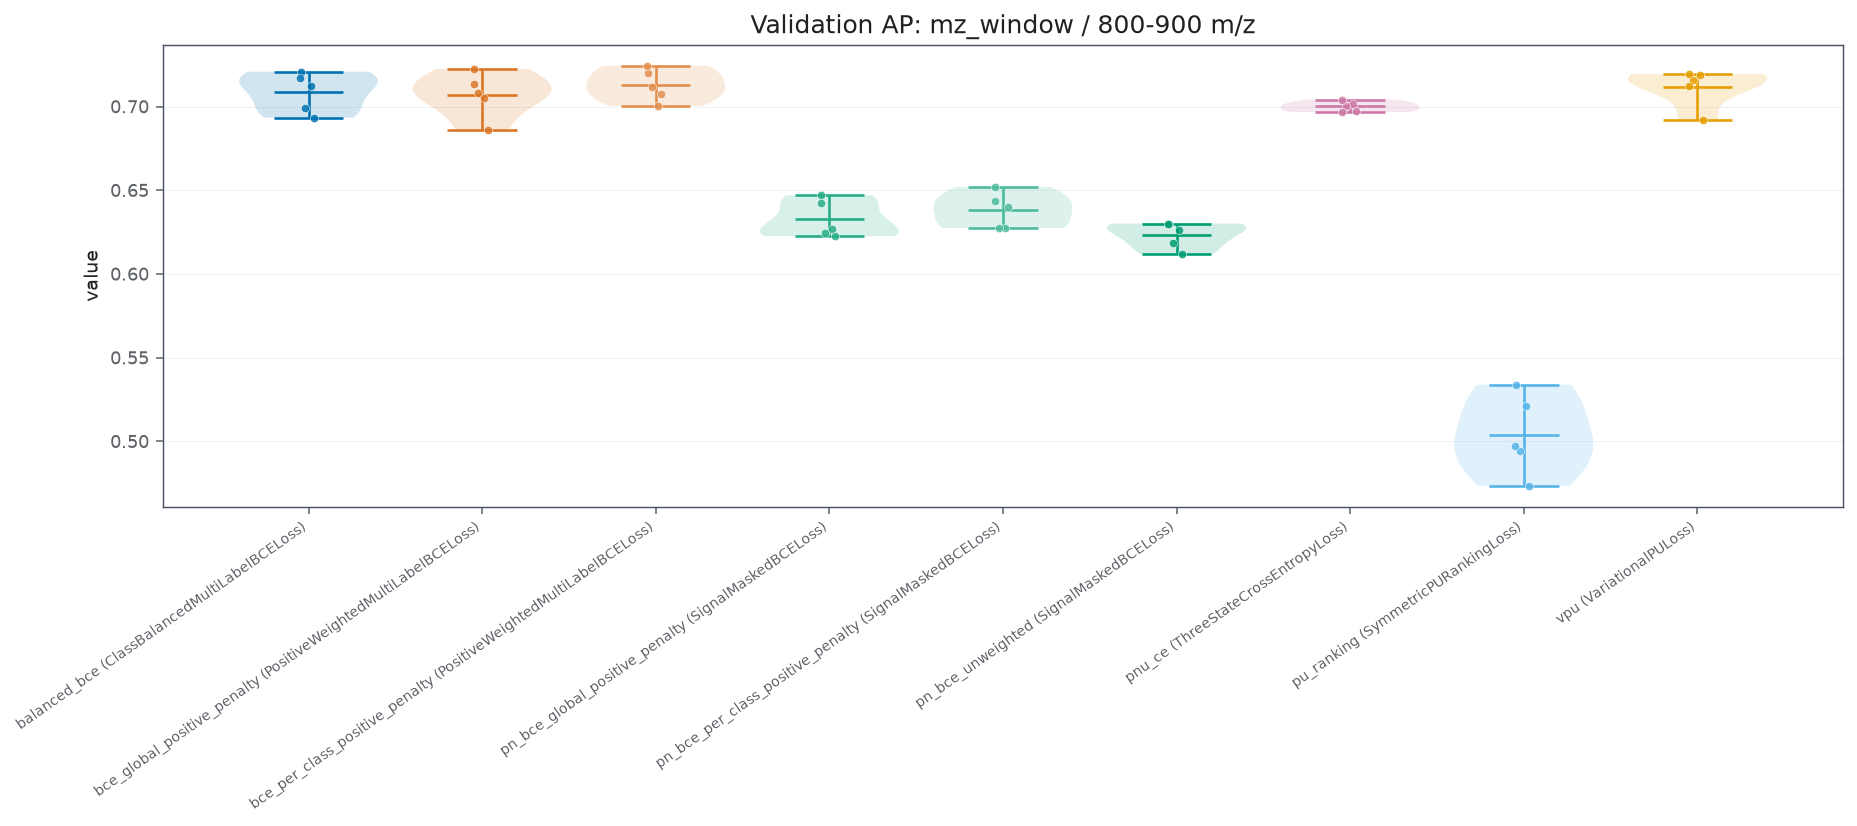

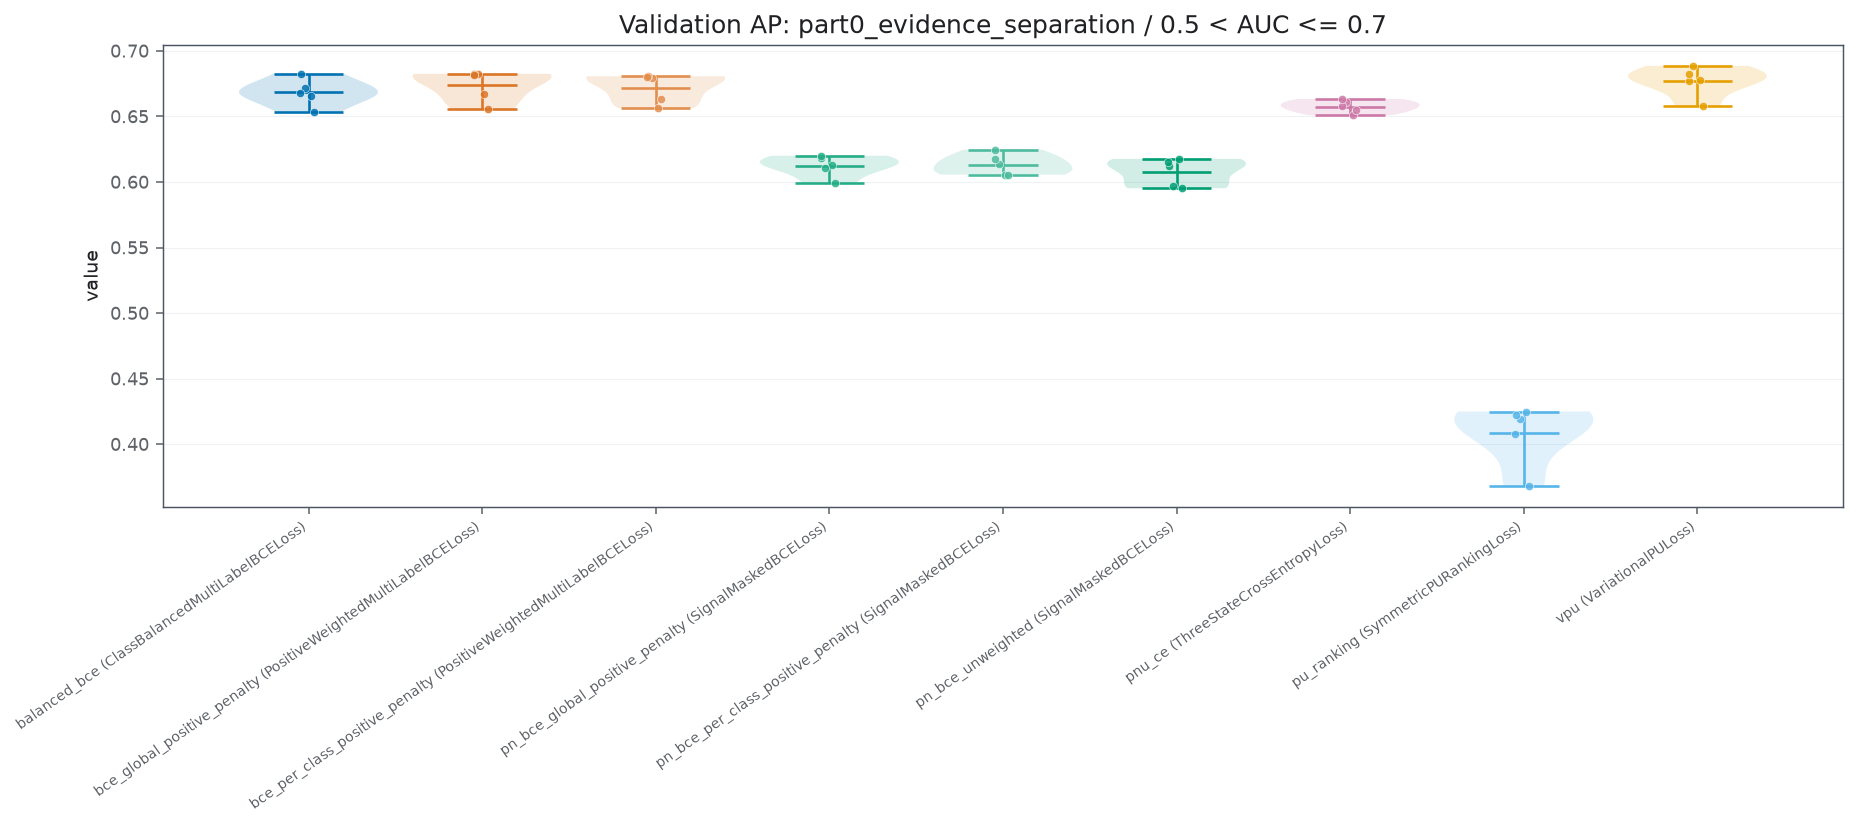

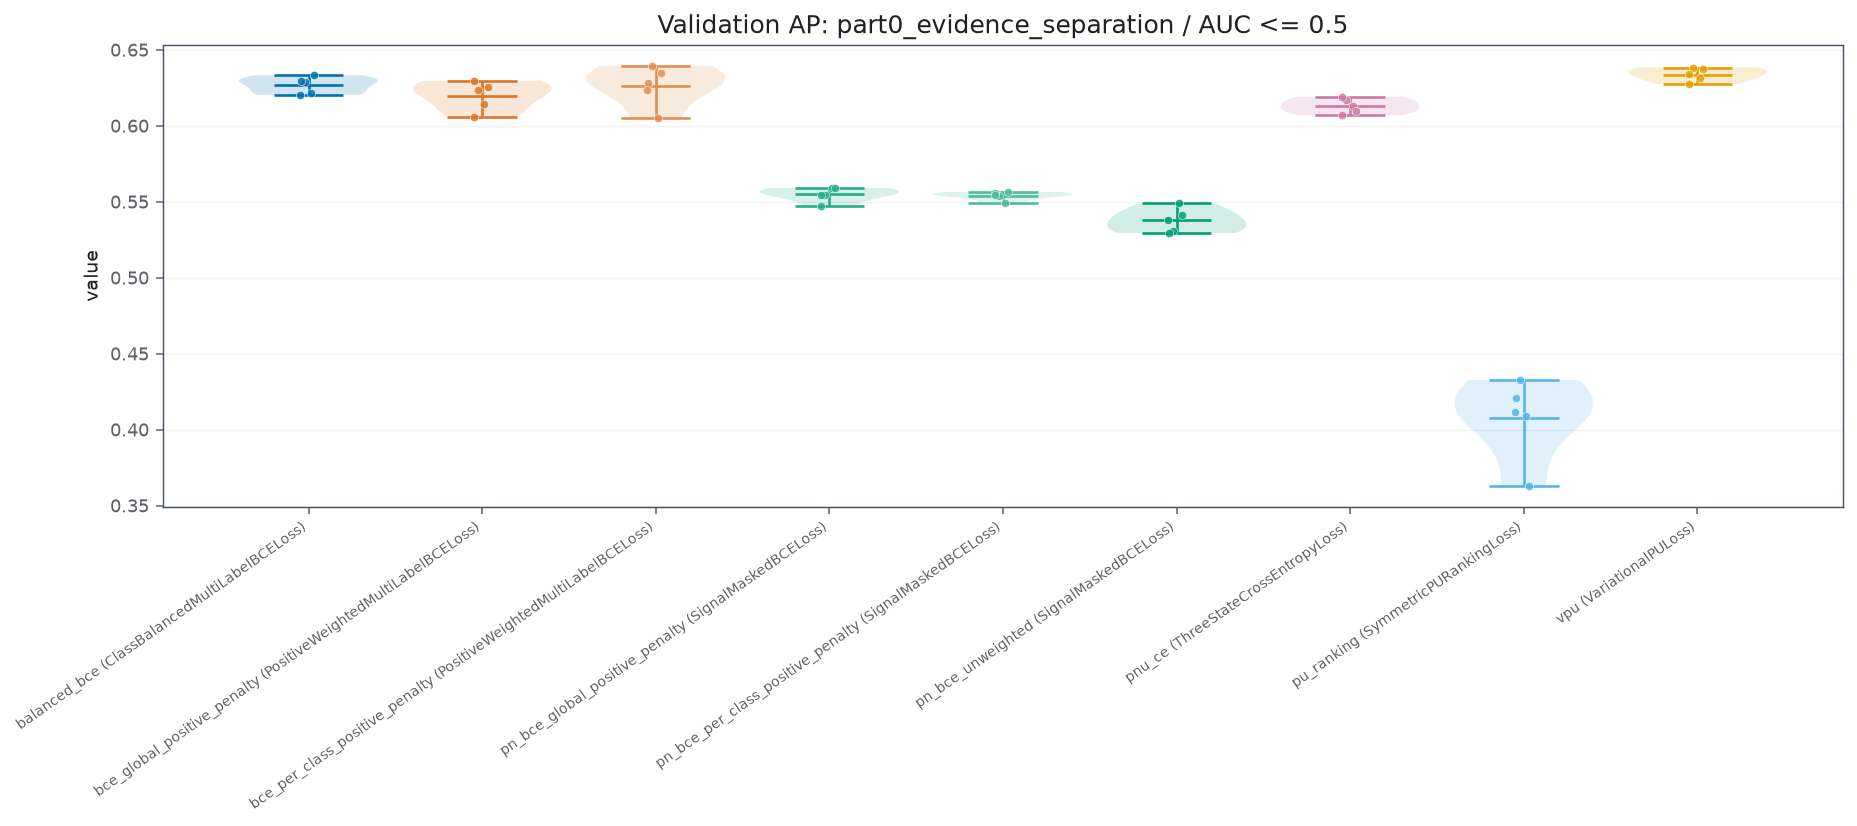

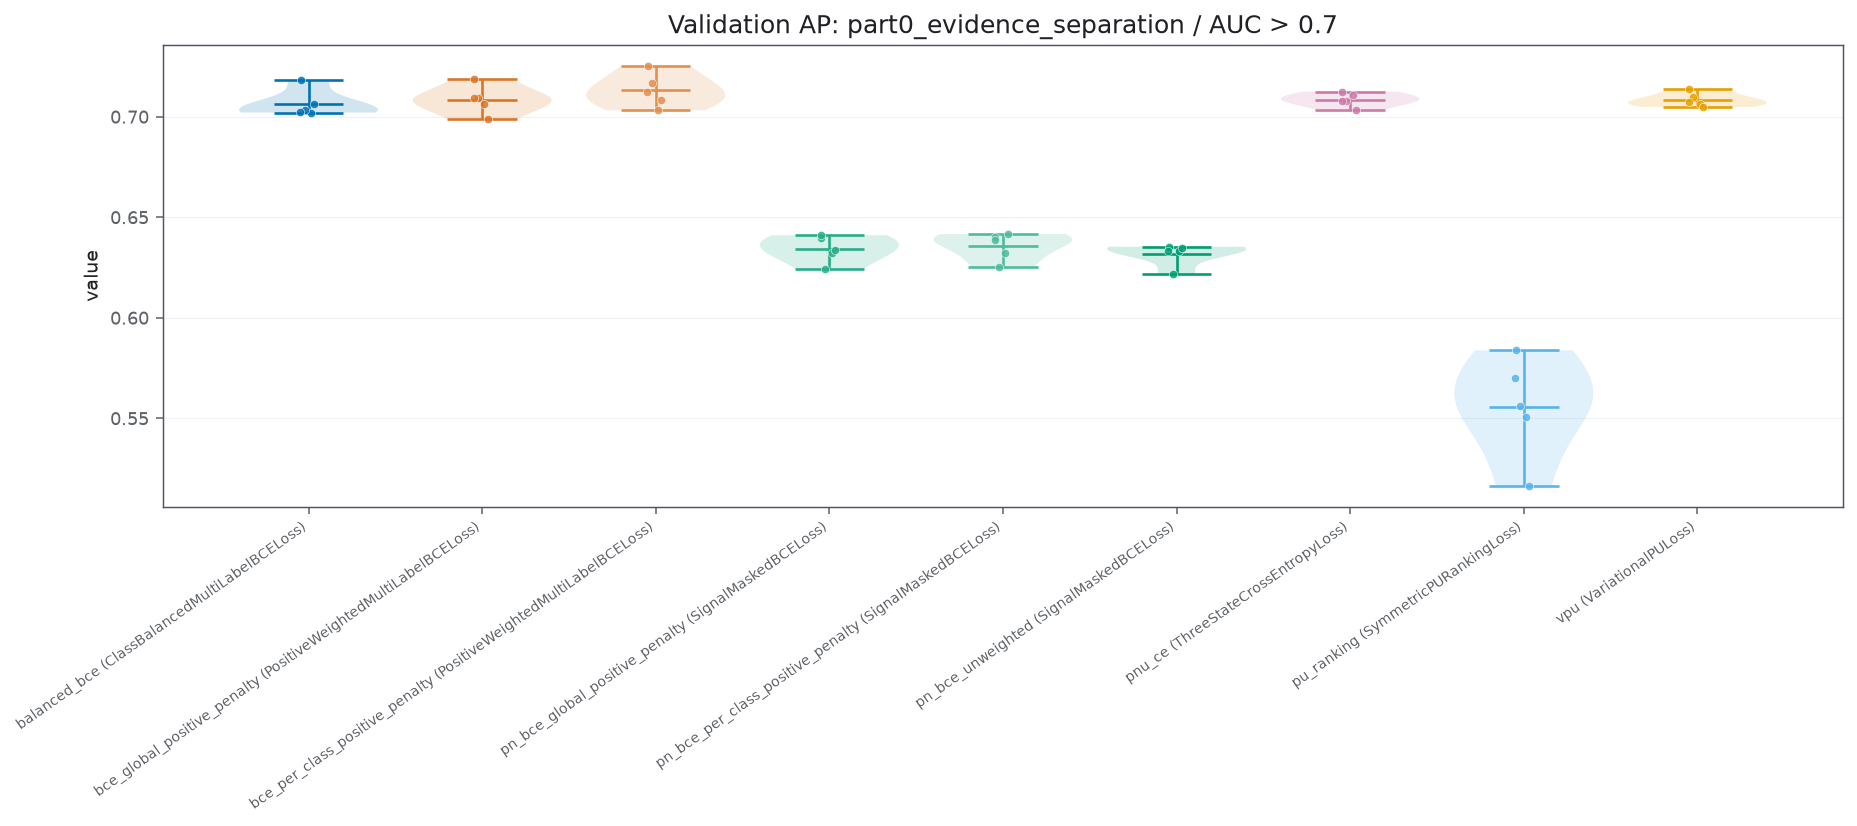

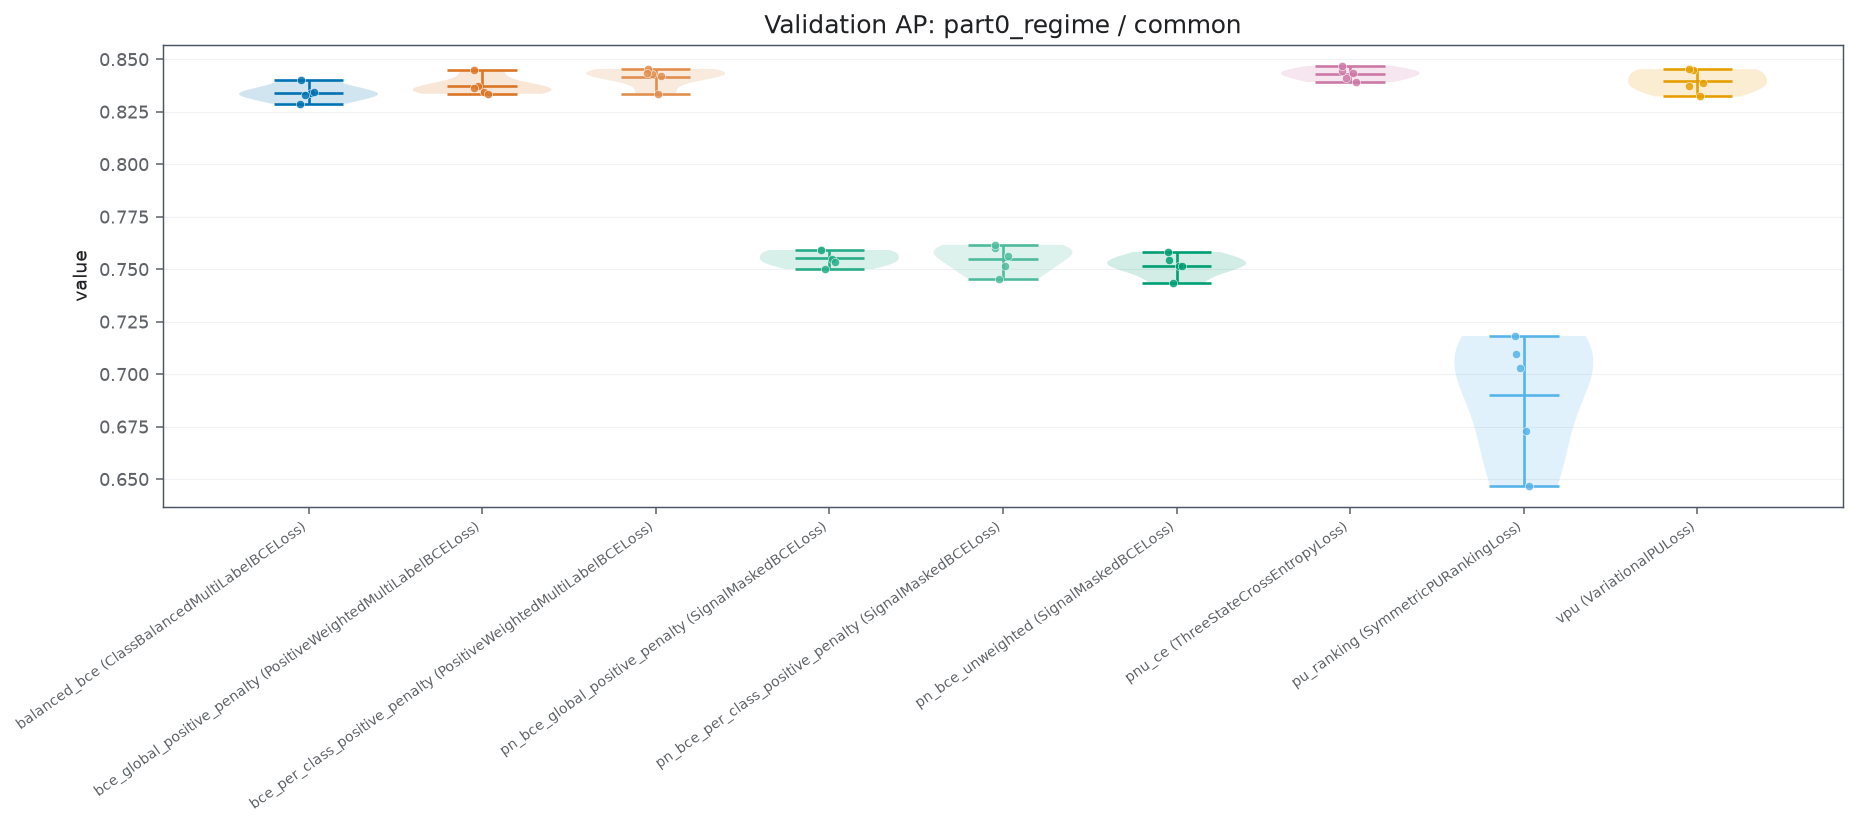

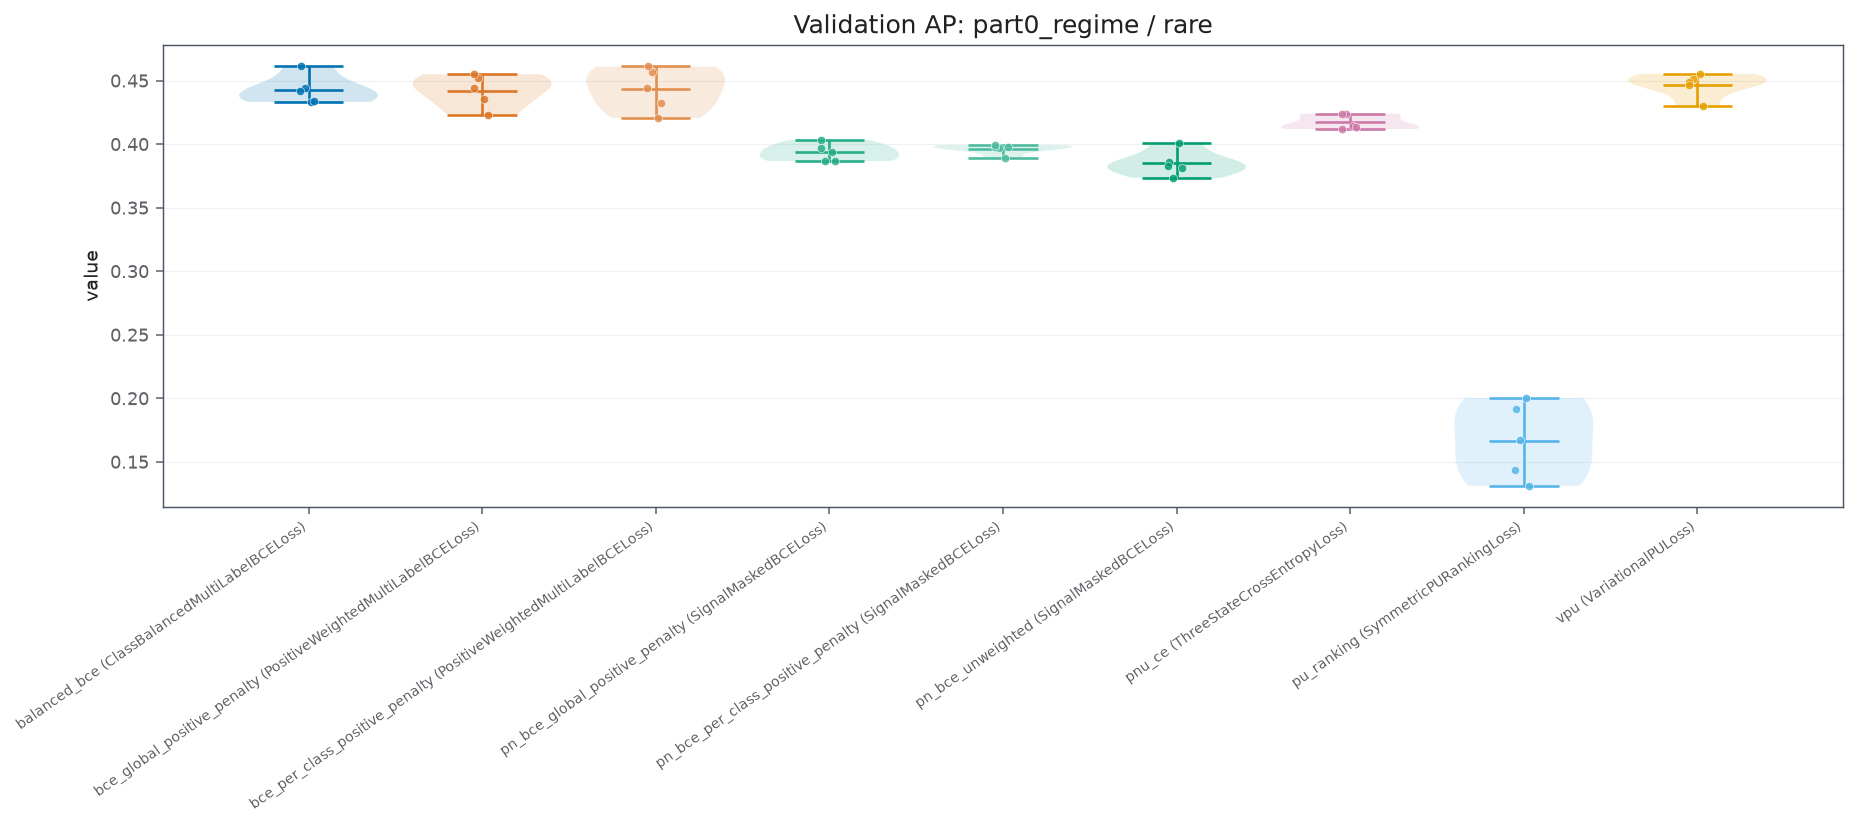

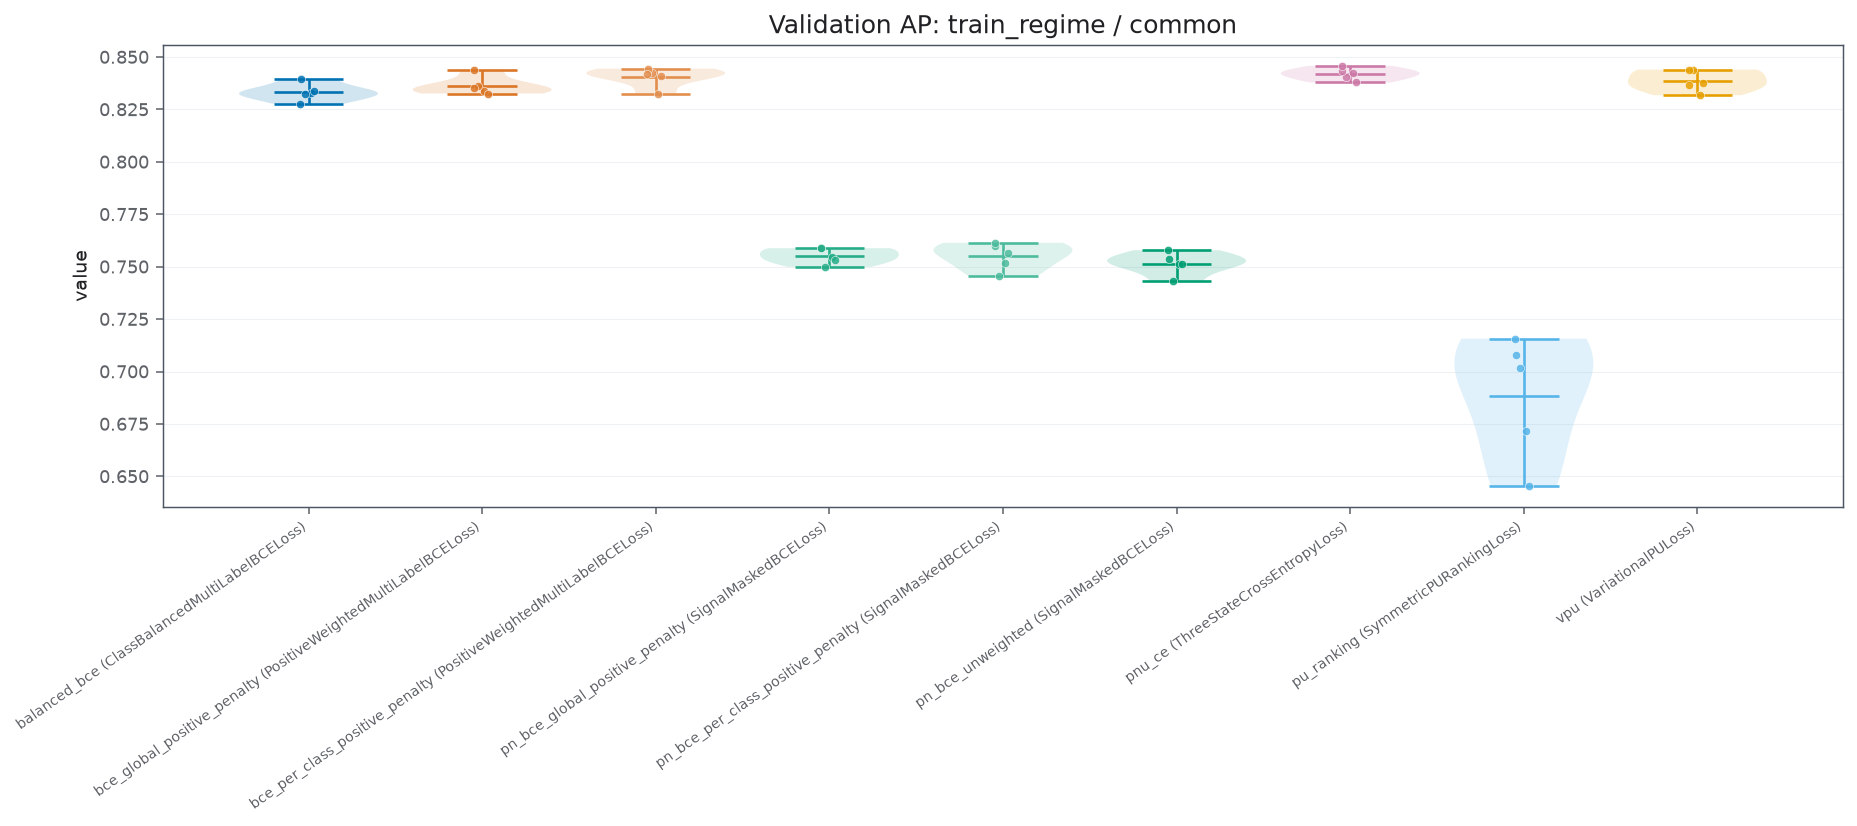

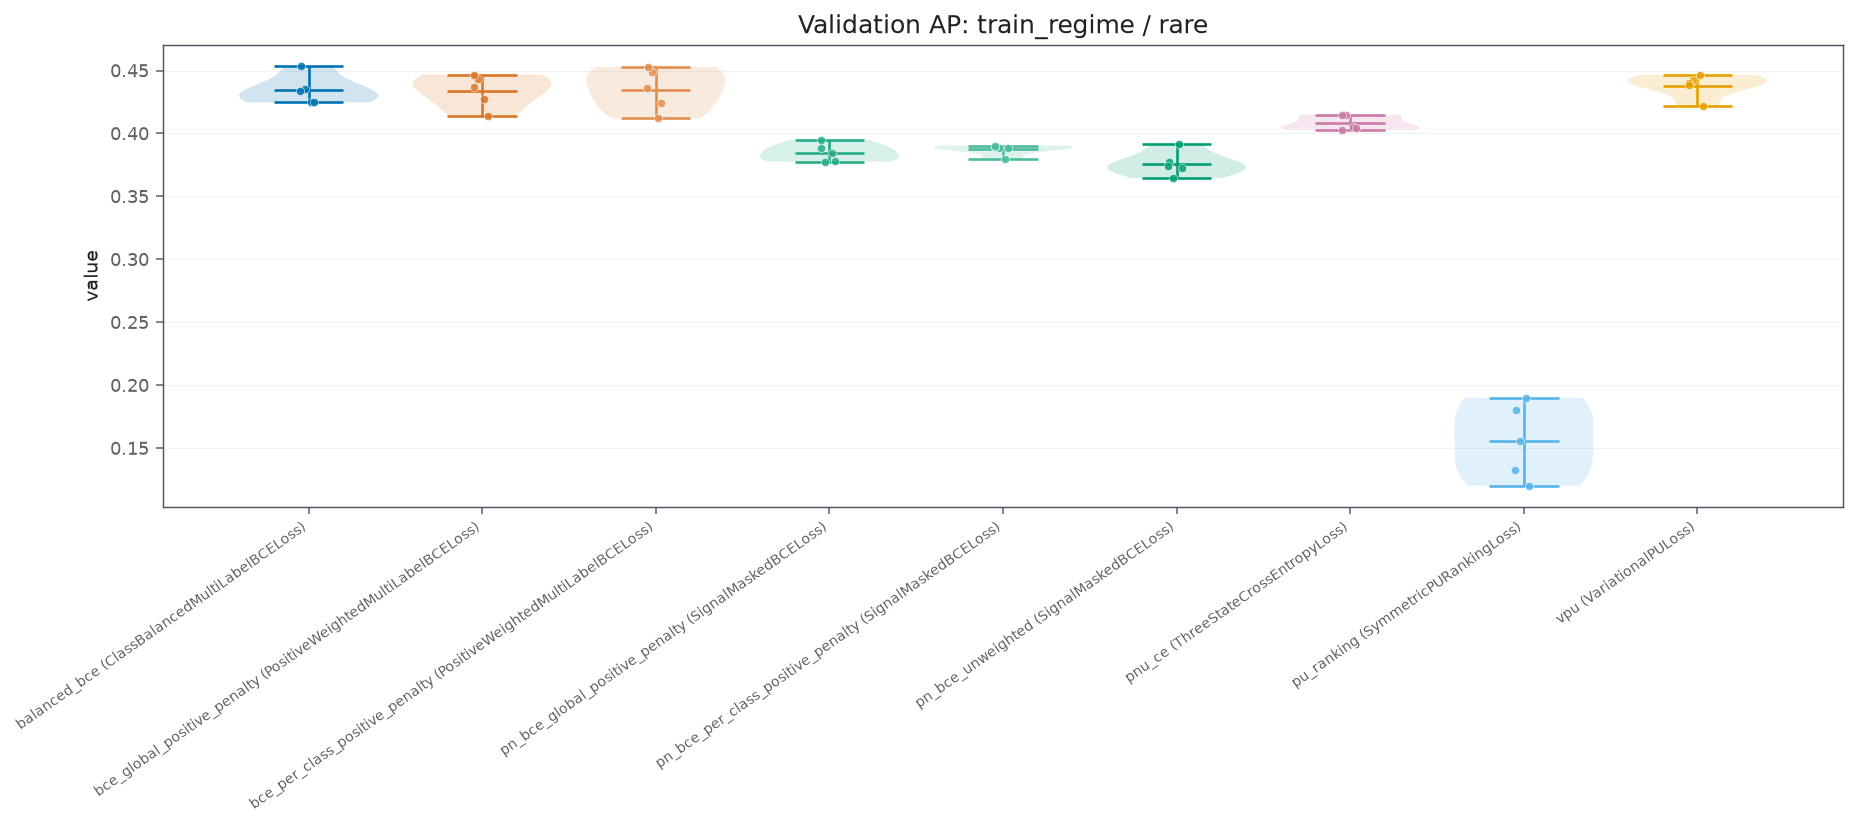

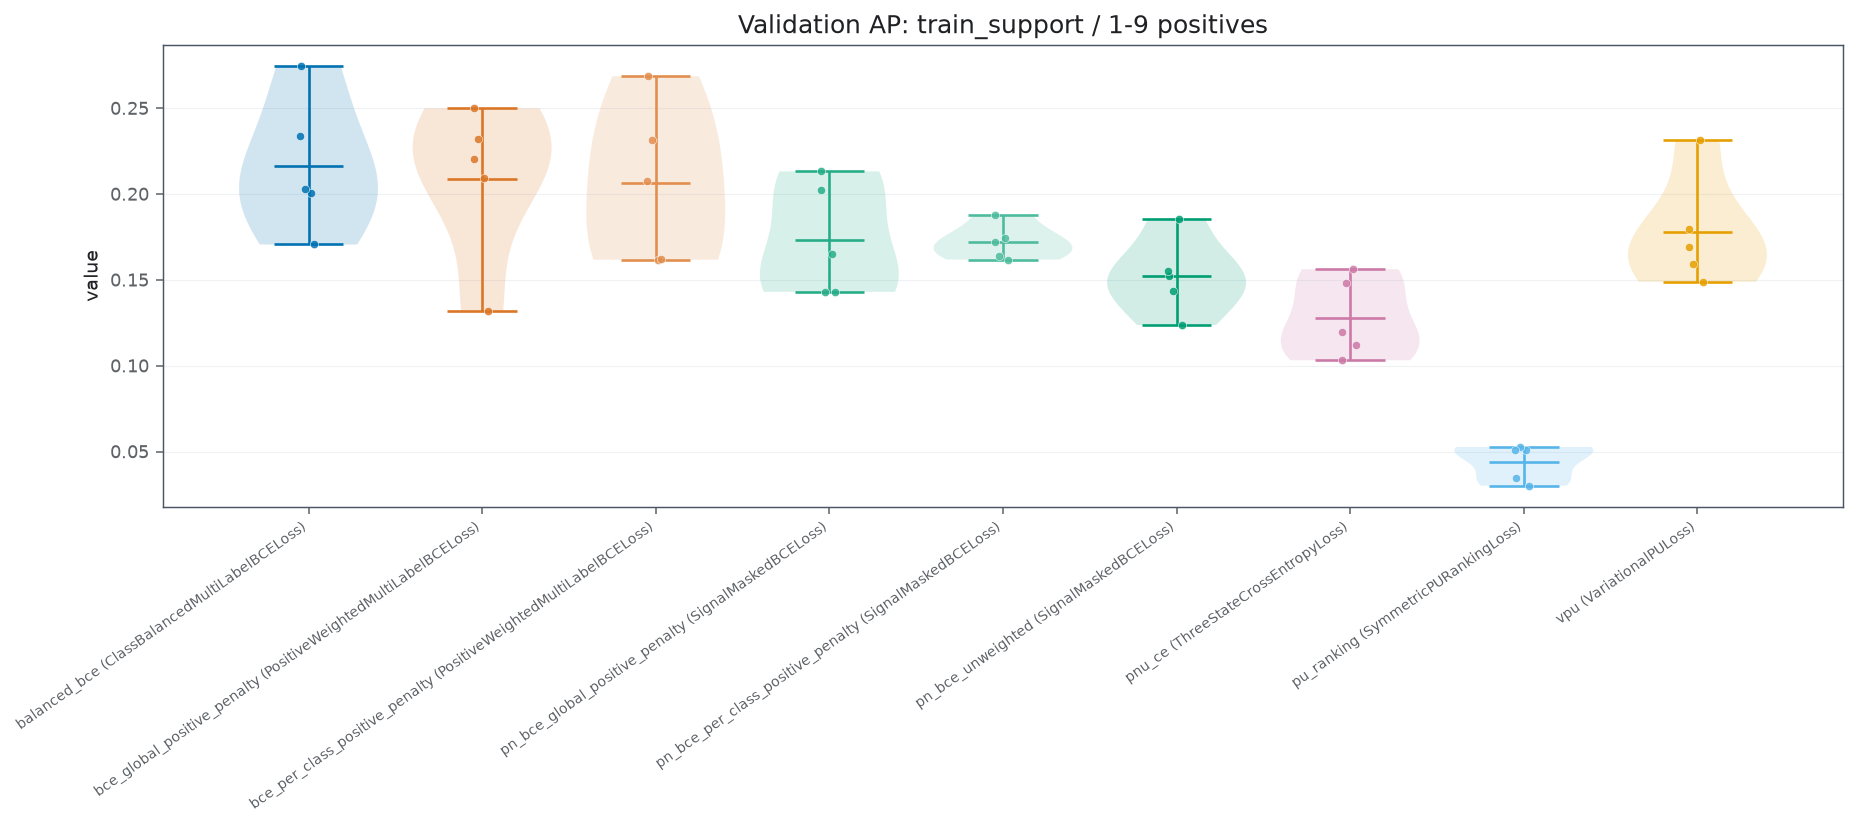

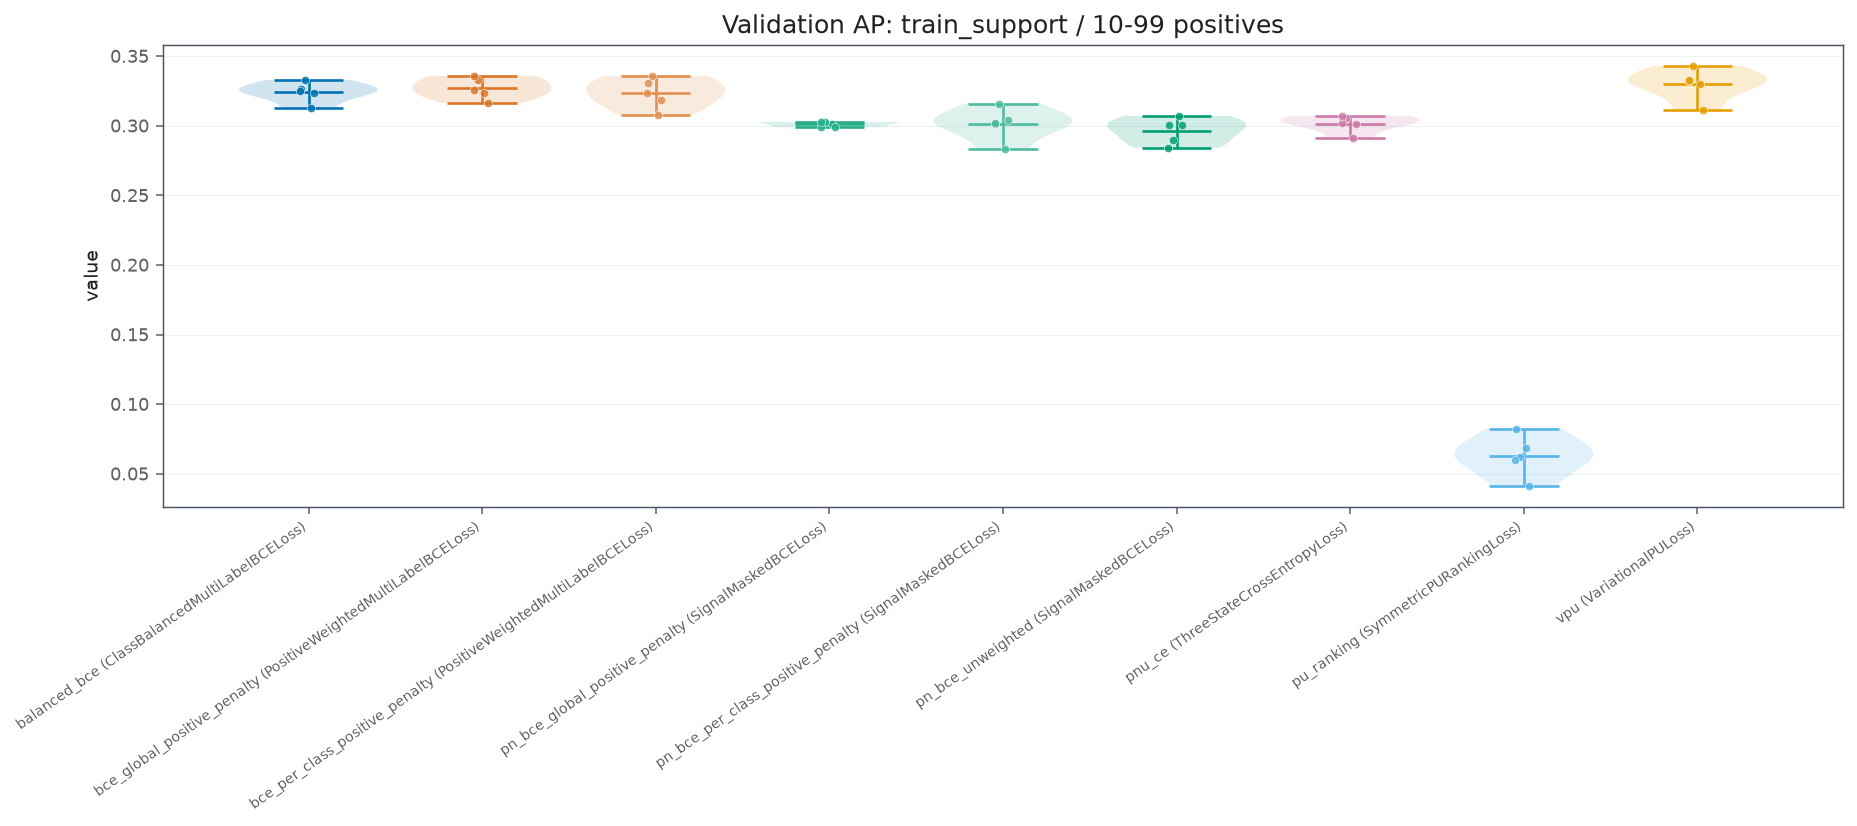

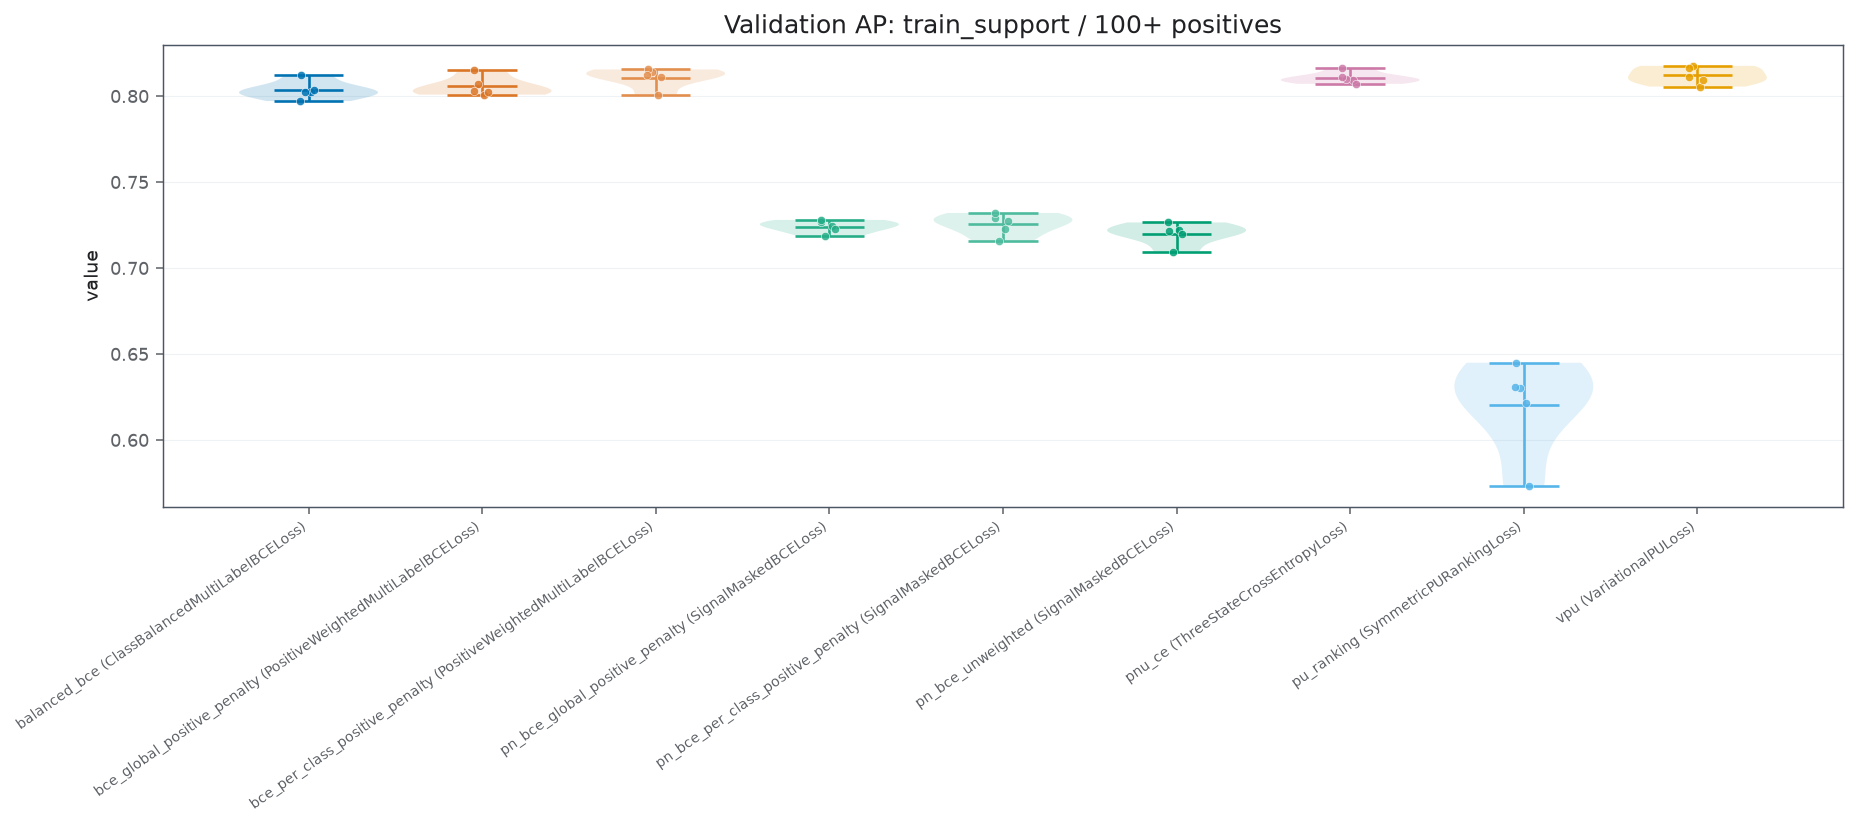

In [3]:
per_class = cache.load_table(settings, "per_class")
enriched, grouped = stratified_metrics(per_class, strata)
models, _ = campaign.inventory(settings)
keys = ["split", "population", "grouping", "stratum", "metric"]
units = reports.experimental_units(grouped, models, keys)
differences, contrasts = reports.paired_comparisons(units, keys)
baseline = contrasts[(contrasts.left_source == "historical_bce") | (contrasts.right_source == "historical_bce")]
split_summary = units.groupby(["label", "split", "population", "grouping", "stratum", "metric"]).value.agg(mean="mean", std="std", seeds="count").reset_index()
display(split_summary.query("metric == 'average_precision' and population == 'annotation_retrieval' and grouping == 'part0_regime'"))
display(grouped[["grouping", "stratum", "split", "population", "total_classes", "eligible_classes"]].drop_duplicates())
display(baseline.query("split == 'validation' and metric == 'average_precision' and population == 'annotation_retrieval'"))
plot_data = units.query("split == 'validation' and population == 'annotation_retrieval' and metric == 'average_precision'")
for (grouping, stratum), frame in plot_data.groupby(["grouping", "stratum"]):
    filename = f"{grouping}_{stratum}".replace("/", "_").replace(" ", "_").replace("<", "lt").replace(">", "gt")
    plots.distributions(frame, title=f"Validation AP: {grouping} / {stratum}").savefig(RESULTS / f"{filename}.png")
reports.save_tables(RESULTS, per_class_stratified=enriched, grouped_metrics=grouped, experimental_units=units,
                    paired_differences=differences, baseline_contrasts=baseline, split_summary=split_summary)

### Remarks

Compare effect sizes within the same fixed group, and inspect support before comparing levels between groups. A gain for operational P/N alone may reflect learning the evidence rule. Rare/common/undetectable membership is mutually exclusive, whereas grouping dimensions overlap; their results are not independent tests.

### Notes


## Class-stratified frozen-encoder probe

### Methodology

#### Theoretical

The shared ridge probe predicts annotation indicators from frozen latent codes. The weights, intercept and standardization are fitted on training data only, using the same squared-error objective and fixed ridge penalty for every encoder (part 6). Applying the same class strata to its validation/test ranking scores helps distinguish performance of the trained head from information accessible through this common linear readout. The difference between head AP and probe AP is descriptive: the two readouts have different capacities and objectives.

#### Implementation

Reuse `probe_per_class` from shared inference. Apply the same identity-checked strata and eligibility rules with `stratified_metrics`, then average duplicate tasks through `experimental_units`. Join head and probe units on condition, actual seeds, contracts, split, population, grouping, stratum and metric. Persist both sets of metrics and their paired differences. No probe is fitted to held-out labels.

#### Figure descriptions

Each figure shows validation annotation-retrieval probe AP for one historical rare/common stratum. The x-axis identifies the encoder's training objective, and the y-axis shows macro AP within that fixed class group. Violins contain the five seed-level observations, with points overlaid; larger AP indicates better ranking through the shared linear probe. Corresponding trained-head plots appear in the preceding section.

### Remarks

An improvement of the trained head without a corresponding probe improvement suggests a readout-dependent gain, but does not prove that the encoder is unchanged. Group-specific differences require the same caution about low class support and exploratory comparisons as the main head analysis.

### Notes


,label,repetition,stratum,value_head,value_probe,head_minus_probe
133,balanced_bce (ClassBalancedMultiLabelBCELoss),0,common,0.833934,0.674844,0.159090
136,balanced_bce (ClassBalancedMultiLabelBCELoss),0,rare,0.433352,0.266822,0.166529
337,balanced_bce (ClassBalancedMultiLabelBCELoss),1,common,0.833130,0.680324,0.152806
340,balanced_bce (ClassBalancedMultiLabelBCELoss),1,rare,0.444177,0.247810,0.196368
541,balanced_bce (ClassBalancedMultiLabelBCELoss),2,common,0.840426,0.701877,0.138549
...,...,...,...,...,...,...
8704,bce_per_class_positive_penalty (PositiveWeight...,2,rare,0.461300,0.247194,0.214106
8905,bce_per_class_positive_penalty (PositiveWeight...,3,common,0.843292,0.689682,0.153609
8908,bce_per_class_positive_penalty (PositiveWeight...,3,rare,0.444460,0.240165,0.204295
9109,bce_per_class_positive_penalty (PositiveWeight...,4,common,0.842025,0.639584,0.202441


2026-09-08 10:29:47,716 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 3 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_8_class_stratification_results.


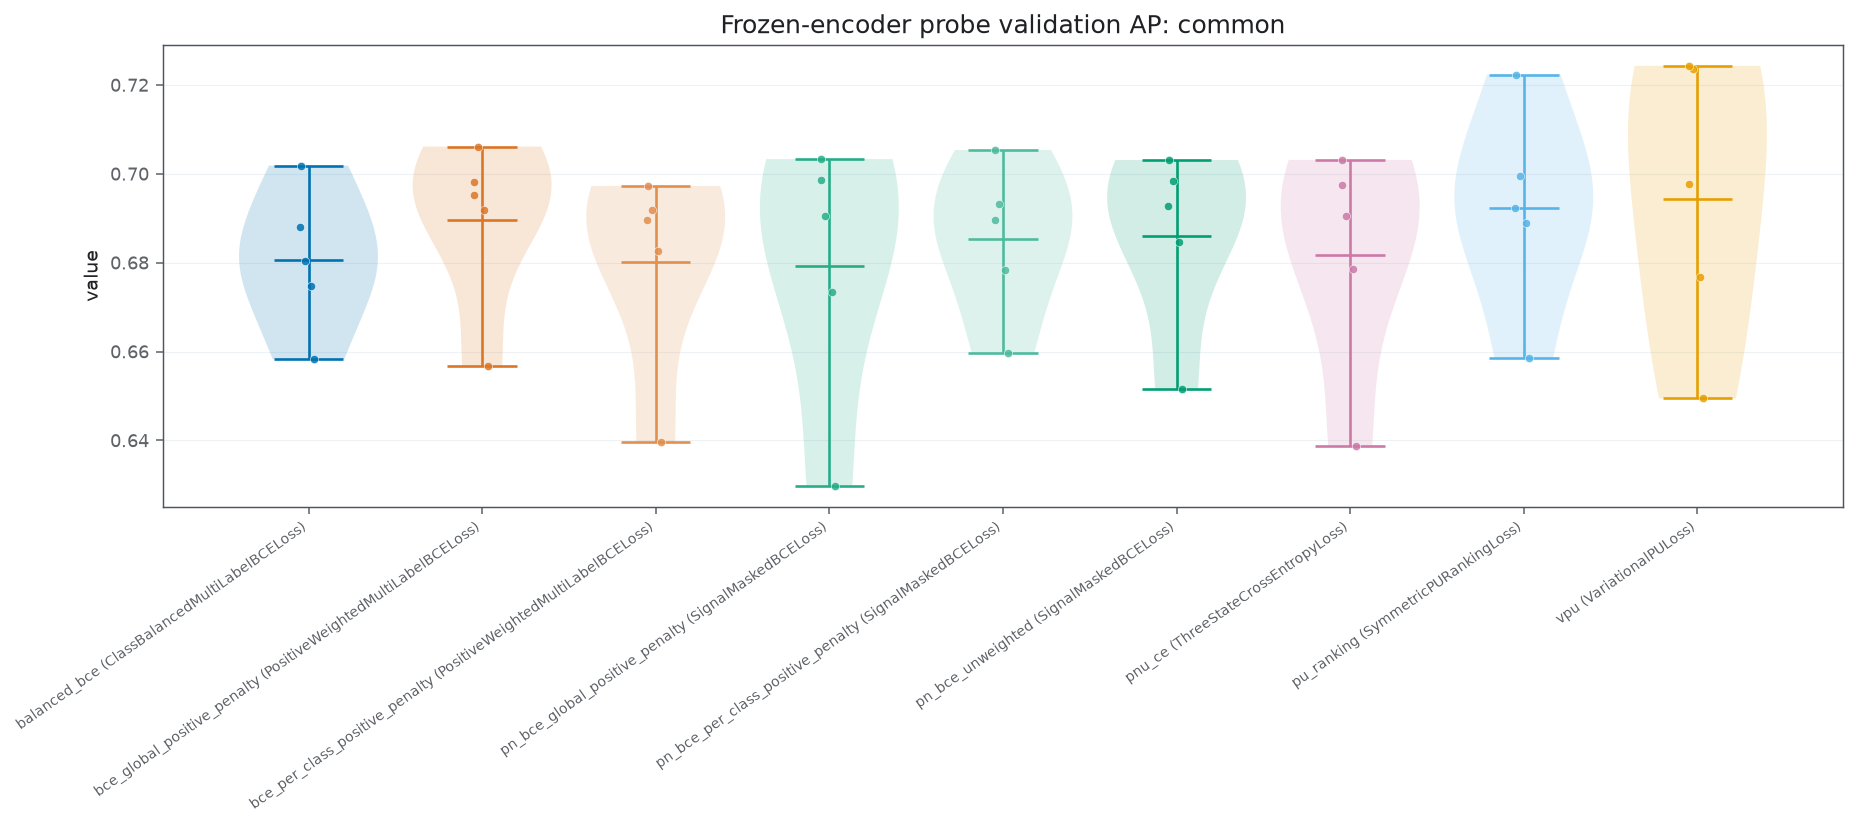

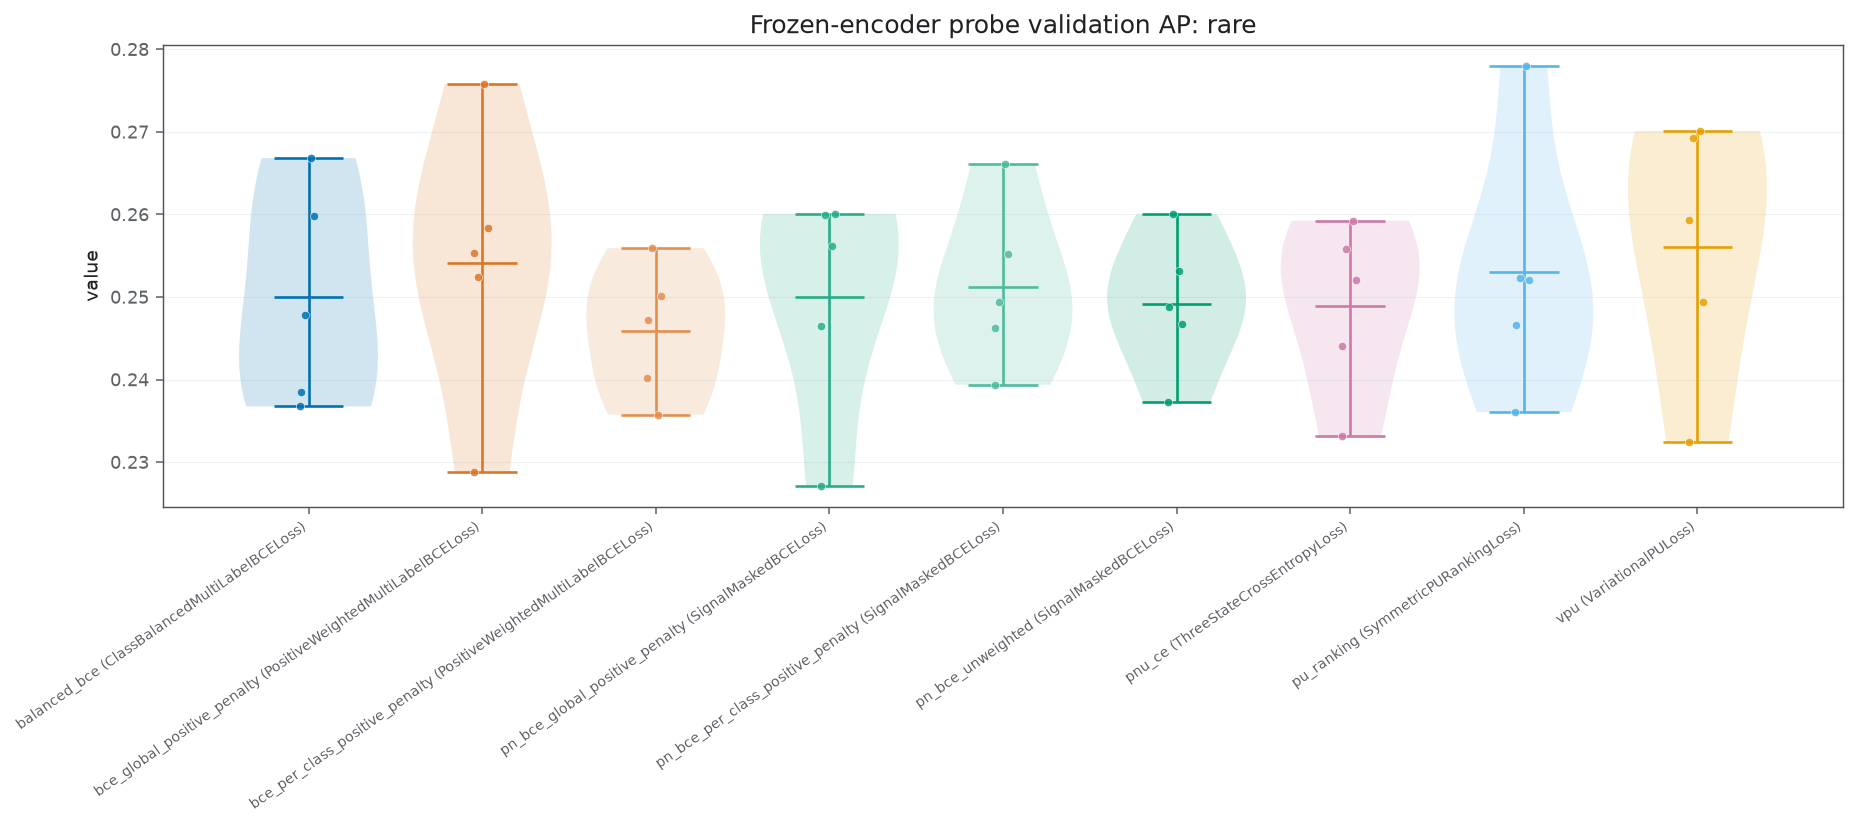

In [4]:
probe_per_class = cache.load_table(settings, "probe_per_class")
_, probe_grouped = stratified_metrics(probe_per_class, strata)
probe_units = reports.experimental_units(probe_grouped, models, keys)
comparison_keys = ["source", "condition", "label", *reports.PAIR_KEYS, *keys]
head_probe = units.merge(probe_units, on=comparison_keys, suffixes=("_head", "_probe"), validate="one_to_one")
head_probe["head_minus_probe"] = head_probe.value_head - head_probe.value_probe
probe_plot = probe_units.query("split == 'validation' and population == 'annotation_retrieval' and metric == 'average_precision' and grouping == 'part0_regime'")
for stratum, frame in probe_plot.groupby("stratum"):
    plots.distributions(frame, title=f"Frozen-encoder probe validation AP: {stratum}").savefig(RESULTS / f"probe_part0_{stratum}.png")
display(head_probe.query("split == 'validation' and population == 'annotation_retrieval' and metric == 'average_precision' and grouping == 'part0_regime'")[["label", "repetition", "stratum", "value_head", "value_probe", "head_minus_probe"]])
reports.save_tables(RESULTS, probe_grouped_metrics=probe_grouped, probe_experimental_units=probe_units, head_probe_comparison=head_probe)


## Results / Summary

### LLM

Execution findings will be recorded after the completed campaign has been evaluated.

### Person
